<div class="usecase-title">{Urban Pedestrian Climate Impact Prediction}</div>

<div class="usecase-authors"><b>Authored by: </b> {Maverick Nguyen}</div>

<div class="usecase-duration"><b>Duration:</b> {90} mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>{Intermediate}</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>{Python, Data Cleaning, Data Validation, Data Visualisation, Time-Series Analysis, Feature Engineering, Optimisation Methods, Deep Learning}</div>
</div>

<div class="usecase-section-header">Scenario</div>

{As a local living near Melbourne CBD, Maverick relies on active travel, like walking, and public transport, like trams, to get around to different places he wants to go. One morning in January, Maverick prepared to travel to his workplace, expecting to get to work before 9:00 AM, but there was a sudden heatwave, causing the tram that he usually catches to be unable to follow its designated schedule and creating a delay in his schedule. Although there was a replacement bus for this emergency, only a limited number of people could board this vehicle, which further delayed his schedule. Because of this sudden extreme weather, travel conditions become less reliable and difficult to predict.

Maverick wants to have access to a system that could predict how climate conditions over time can affect urban pedestrian movement. So that he could better plan his trip, allowing him to leave earlier in anticipation of sudden extreme weather change during a particular timeframe, or choose a different mode of transport, like an Uber. This allows more support in making informed decisions when travelling during extreme weather events.}

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case, you will:
- {Learn how to source and combine multiple public datasets.  
- Understand how to clean and align time-series data at an hourly level for modelling. 
- Explore how climate variables, such as temperature, humidity, pressure, and wind, relate to pedestrian counts.
- Apply feature engineering techniques to create meaningful predictors from weather and mobility time-series data. 
- Build a deep learning forecasting model to predict pedestrian demand. 
- Perform model optimisation like hyperparameter tuning to improve forecasting performance. 
- Evaluate model performance and interpret results for climate adaptation planning.}

<div class="usecase-section-header">{Introduction}</div>

{Urban systems are often affected by changing climate conditions, but these effects are not always easy to capture with simple forecasting methods. One clear example is pedestrian movement, where changing weather conditions can affect how many people move through the city over time.

This use case focuses on predicting pedestrian activity in the City of Melbourne using hourly climate observations, which keeps the project closely aligned with the goal of modelling how climate factors influence an urban system.

In this use case, pedestrian counts are aggregated into hourly city-level totals and merged with hourly microclimate observations for Melbourne. A deep learning model can then be trained to predict pedestrian demand based on time, recent demand history, and recent climate conditions.

The datasets used in this project are the "Pedestrian Counting System (counts per hour)", the "Pedestrian Counting System - Sensor Locations" dataset for supporting location metadata, and the "Microclimate Sensor Readings" dataset from the City of Melbourne website.}

## 1. Importing The Libraries

In [10]:
# Libraries for this project.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler

## 2. Importing The Datasets

In [12]:
# Store the API base path.
BASE_URL = (
    "https://data.melbourne.vic.gov.au"
    "/api/explore/v2.1/catalog/datasets"
)

# Store the dataset identifiers.
DATASETS = {
    "sensor_locations":
        "pedestrian-counting-system-sensor-locations",
    "pedestrian_counts":
        "pedestrian-counting-system-monthly-counts-per-hour",
    "microclimate":
        "microclimate-sensors-data",
}

# Set the number of rows to retrieve for experiments.
# Change to "None" when full datasets are needed.
# Change to an integer for experimental purposes.
ROW_LIMIT = None 

def get_csv_url(dataset_id, row_limit=None):
    # Build the base CSV export URL.
    url = (
        f"{BASE_URL}/{dataset_id}/exports/csv"
        f"?delimiter=,&with_bom=true"
    )

    # Add a row limit if one is provided.
    if row_limit is not None:
        url += f"&limit={row_limit}"

    return url

### 2.1 Pedestrian Counting System - Sensor Locations

In [14]:
# Load the sensor locations dataset.
sensor_locations_df = pd.read_csv(
    get_csv_url(
        DATASETS["sensor_locations"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(sensor_locations_df.head())

   location_id             sensor_description sensor_name installation_date  \
0            1     Bourke Street Mall (North)    Bou292_T        2009-03-24   
1            4               Town Hall (West)    Swa123_T        2009-03-23   
2           10                 Victoria Point    BouHbr_T        2009-04-23   
3           11                Waterfront City    WatCit_T        2009-01-20   
4           24  Spencer St-Collins St (North)    Col620_T        2013-09-02   

  note location_type status direction_1 direction_2   latitude   longitude  \
0  NaN       Outdoor      A        East        West -37.813494  144.965153   
1  NaN       Outdoor      A       North       South -37.814880  144.966088   
2  NaN       Outdoor      A        East        West -37.818765  144.947105   
3  NaN       Outdoor      A        East        West -37.815650  144.939707   
4  NaN       Outdoor      A        East        West -37.818880  144.954492   

                     location  
0  -37.81349441, 144.965

### 2.2 Pedestrian Counting System (counts per hour)

In [16]:
# Load the pedestrian counts dataset.
pedestrian_counts_df = pd.read_csv(
    get_csv_url(
        DATASETS["pedestrian_counts"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(pedestrian_counts_df.head())

              id  location_id sensing_date  hourday  direction_1  direction_2  \
0  1662020241206          166   2024-12-06       20           12           10   
1  1431320240504          143   2024-05-04       13          376          455   
2  1431120250514          143   2025-05-14       11          114          214   
3  1321320250811          132   2025-08-11       13          180          158   
4   133320260308          133   2026-03-08        3           36           23   

   pedestriancount sensor_name                    location  
0               22   Spen484_T  -37.80896733, 144.94931703  
1              831   Spencer_T    -37.821728, 144.95557015  
2              328   Spencer_T    -37.821728, 144.95557015  
3              338   King335_T  -37.81267639, 144.95386444  
4               59   Spen229_T  -37.81531435, 144.95227769  


### 2.3 Microclimate sensors data

In [18]:
# Load the microclimate dataset.
microclimate_df = pd.read_csv(
    get_csv_url(
        DATASETS["microclimate"],
        row_limit=ROW_LIMIT
    ),
    encoding="utf-8-sig"
)

# Preview the dataframe.
print(microclimate_df.head())

            device_id                received_at  \
0  ICTMicroclimate-09  2025-11-16T03:47:32+00:00   
1  ICTMicroclimate-03  2025-11-16T04:14:45+00:00   
2  ICTMicroclimate-05  2025-08-23T18:58:22+00:00   
3  ICTMicroclimate-01  2025-08-23T18:57:53+00:00   
4  ICTMicroclimate-11  2025-08-23T15:31:41+00:00   

                                      sensorlocation  \
0  SkyFarm (Jeff's Shed). Rooftop - Melbourne Con...   
1                                        CH1 rooftop   
2                 Enterprize Park - Pole ID: COM1667   
3                    Birrarung Marr Park - Pole 1131   
4                                   1 Treasury Place   

                    latlong  minimumwinddirection  averagewinddirection  \
0  -37.8223306, 144.9521696                   0.0                   0.0   
1    -37.8140348, 144.96728                 187.0                 240.0   
2  -37.8204083, 144.9591192                   0.0                   0.0   
3  -37.8185931, 144.9716404                   NaN 

## 3. Initial Inspection Of The Datasets

### 3.1 Checking Number Of Rows/Columns

In [21]:
# Preview of the number of columns and rows.
print(sensor_locations_df.shape)
print(pedestrian_counts_df.shape)
print(microclimate_df.shape)

(145, 12)
(1467188, 9)
(591803, 16)


### 3.2 Checking The Features

In [23]:
# Check the column names for each dataframe.
print("Sensor locations columns:")
print(sensor_locations_df.columns)

print("\nPedestrian counts columns:")
print(pedestrian_counts_df.columns)

print("\nMicroclimate columns:")
print(microclimate_df.columns)

Sensor locations columns:
Index(['location_id', 'sensor_description', 'sensor_name', 'installation_date',
       'note', 'location_type', 'status', 'direction_1', 'direction_2',
       'latitude', 'longitude', 'location'],
      dtype='object')

Pedestrian counts columns:
Index(['id', 'location_id', 'sensing_date', 'hourday', 'direction_1',
       'direction_2', 'pedestriancount', 'sensor_name', 'location'],
      dtype='object')

Microclimate columns:
Index(['device_id', 'received_at', 'sensorlocation', 'latlong',
       'minimumwinddirection', 'averagewinddirection', 'maximumwinddirection',
       'minimumwindspeed', 'averagewindspeed', 'gustwindspeed',
       'airtemperature', 'relativehumidity', 'atmosphericpressure', 'pm25',
       'pm10', 'noise'],
      dtype='object')


### 3.3 Checking The Datatypes

In [25]:
# Check the data types for each dataframe.
print("Sensor locations data types:")
print(sensor_locations_df.dtypes)

print("\nPedestrian counts data types:")
print(pedestrian_counts_df.dtypes)

print("\nMicroclimate data types:")
print(microclimate_df.dtypes)

Sensor locations data types:
location_id             int64
sensor_description     object
sensor_name            object
installation_date      object
note                   object
location_type          object
status                 object
direction_1            object
direction_2            object
latitude              float64
longitude             float64
location               object
dtype: object

Pedestrian counts data types:
id                  int64
location_id         int64
sensing_date       object
hourday             int64
direction_1         int64
direction_2         int64
pedestriancount     int64
sensor_name        object
location           object
dtype: object

Microclimate data types:
device_id                object
received_at              object
sensorlocation           object
latlong                  object
minimumwinddirection    float64
averagewinddirection    float64
maximumwinddirection    float64
minimumwindspeed        float64
averagewindspeed        float64
gust

### 3.4 Checking The Dataset Information

In [27]:
# Check the overall structure of each dataframe.
print("Sensor locations info:")
print(sensor_locations_df.info())

print("\nPedestrian counts info:")
print(pedestrian_counts_df.info())

print("\nMicroclimate info:")
print(microclimate_df.info())

Sensor locations info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   location_id         145 non-null    int64  
 1   sensor_description  145 non-null    object 
 2   sensor_name         145 non-null    object 
 3   installation_date   145 non-null    object 
 4   note                34 non-null     object 
 5   location_type       145 non-null    object 
 6   status              145 non-null    object 
 7   direction_1         113 non-null    object 
 8   direction_2         113 non-null    object 
 9   latitude            145 non-null    float64
 10  longitude           145 non-null    float64
 11  location            145 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 13.7+ KB
None

Pedestrian counts info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467188 entries, 0 to 1467187
Data columns 

### 3.5 Checking For Missing Values

In [29]:
# Count the missing values in each dataframe.
print("Missing values in sensor locations:")
print(sensor_locations_df.isna().sum())

print("\nMissing values in pedestrian counts:")
print(pedestrian_counts_df.isna().sum())

print("\nMissing values in microclimate:")
print(microclimate_df.isna().sum())

Missing values in sensor locations:
location_id             0
sensor_description      0
sensor_name             0
installation_date       0
note                  111
location_type           0
status                  0
direction_1            32
direction_2            32
latitude                0
longitude               0
location                0
dtype: int64

Missing values in pedestrian counts:
id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

Missing values in microclimate:
device_id                   0
received_at                 0
sensorlocation           6143
latlong                 11483
minimumwinddirection    61942
averagewinddirection      649
maximumwinddirection    62104
minimumwindspeed        62104
averagewindspeed          651
gustwindspeed           62104
airtemperature            651
relativehumidity          651
atmosp

### 3.6 Checking Summary Statistics

In [31]:
# Check the summary statistics for numeric columns.
print("Sensor locations summary:")
print(sensor_locations_df.describe())

print("\nPedestrian counts summary:")
print(pedestrian_counts_df.describe())

print("\nMicroclimate summary:")
print(microclimate_df.describe())

Sensor locations summary:
       location_id    latitude   longitude
count   145.000000  145.000000  145.000000
mean     93.075862  -37.812392  144.960427
std      55.229079    0.006999    0.009594
min       1.000000  -37.825910  144.928606
25%      47.000000  -37.816888  144.956447
50%      89.000000  -37.813625  144.961860
75%     142.000000  -37.807767  144.965626
max     188.000000  -37.789353  144.986388

Pedestrian counts summary:
                 id   location_id       hourday   direction_1   direction_2  \
count  1.467188e+06  1.467188e+06  1.467188e+06  1.467188e+06  1.467188e+06   
mean   4.795108e+11  7.261683e+01  1.182818e+01  1.882640e+02  1.932120e+02   
std    5.112231e+11  5.013167e+01  6.778191e+00  2.926373e+02  3.031645e+02   
min    1.020240e+09  1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    6.912024e+10  3.100000e+01  6.000000e+00  1.800000e+01  1.900000e+01   
50%    2.511203e+11  6.200000e+01  1.200000e+01  7.800000e+01  7.700000e+01   
75%   

### 3.7 Checking The Date Format

In [33]:
# Check a few date values before conversion.
print("Pedestrian sensing_date sample:")
print(pedestrian_counts_df["sensing_date"].head())

print("\nMicroclimate received_at sample:")
print(microclimate_df["received_at"].head())

print("\nSensor installation_date sample:")
print(sensor_locations_df["installation_date"].head())

Pedestrian sensing_date sample:
0    2024-12-06
1    2024-05-04
2    2025-05-14
3    2025-08-11
4    2026-03-08
Name: sensing_date, dtype: object

Microclimate received_at sample:
0    2025-11-16T03:47:32+00:00
1    2025-11-16T04:14:45+00:00
2    2025-08-23T18:58:22+00:00
3    2025-08-23T18:57:53+00:00
4    2025-08-23T15:31:41+00:00
Name: received_at, dtype: object

Sensor installation_date sample:
0    2009-03-24
1    2009-03-23
2    2009-04-23
3    2009-01-20
4    2013-09-02
Name: installation_date, dtype: object


### 3.8 Checking The ID Columns

In [35]:
# Check important identifier columns.
print("Unique location_id values in sensor locations:")
print(sensor_locations_df["location_id"].nunique())

print("\nUnique location_id values in pedestrian counts:")
print(pedestrian_counts_df["location_id"].nunique())

print("\nUnique device_id values in microclimate:")
print(microclimate_df["device_id"].nunique())

Unique location_id values in sensor locations:
137

Unique location_id values in pedestrian counts:
100

Unique device_id values in microclimate:
12


## 4. Data Cleaning

### 4.1 Removing Irrelevant Columns

In [38]:
# Keep only useful columns.
sensor_locations_clean = sensor_locations_df[
    [
        "location_id",
        "sensor_description",
        "installation_date",
        "status",
        "latitude",
        "longitude",
    ]
].copy()

pedestrian_clean = pedestrian_counts_df[
    [
        "location_id",
        "sensing_date",
        "hourday",
        "pedestriancount",
    ]
].copy()

microclimate_clean = microclimate_df[
    [
        "device_id",
        "received_at",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "averagewinddirection",
        "pm25",
        "pm10",
        "noise",
    ]
].copy()

# Check the result.
print(sensor_locations_clean.head())
print(pedestrian_clean.head())
print(microclimate_clean.head())

   location_id             sensor_description installation_date status  \
0            1     Bourke Street Mall (North)        2009-03-24      A   
1            4               Town Hall (West)        2009-03-23      A   
2           10                 Victoria Point        2009-04-23      A   
3           11                Waterfront City        2009-01-20      A   
4           24  Spencer St-Collins St (North)        2013-09-02      A   

    latitude   longitude  
0 -37.813494  144.965153  
1 -37.814880  144.966088  
2 -37.818765  144.947105  
3 -37.815650  144.939707  
4 -37.818880  144.954492  
   location_id sensing_date  hourday  pedestriancount
0          166   2024-12-06       20               22
1          143   2024-05-04       13              831
2          143   2025-05-14       11              328
3          132   2025-08-11       13              338
4          133   2026-03-08        3               59
            device_id                received_at  airtemperature  \
0

### 4.2 Removing Missing Value

In [40]:
# Check missing values after column selection.
print("Missing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())

Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64

Missing values in microclimate_clean:
device_id                   0
received_at                 0
airtemperature            651
relativehumidity          651
atmosphericpressure       651
averagewindspeed          651
gustwindspeed           62104
averagewinddirection      649
pm25                    31387
pm10                    31387
noise                   31387
dtype: int64


In [41]:
# Remove rows with any missing values from each dataset.
sensor_locations_clean = sensor_locations_clean.dropna().copy()
pedestrian_clean = pedestrian_clean.dropna().copy()
microclimate_clean = microclimate_clean.dropna().copy()

# Check missing values after removal.
print("\nMissing values in sensor_locations_clean:")
print(sensor_locations_clean.isna().sum())
print(sensor_locations_clean.shape)

print("\nMissing values in pedestrian_clean:")
print(pedestrian_clean.isna().sum())
print(pedestrian_clean.shape)

print("\nMissing values in microclimate_clean:")
print(microclimate_clean.isna().sum())
print(microclimate_clean.shape)


Missing values in sensor_locations_clean:
location_id           0
sensor_description    0
installation_date     0
status                0
latitude              0
longitude             0
dtype: int64
(145, 6)

Missing values in pedestrian_clean:
location_id        0
sensing_date       0
hourday            0
pedestriancount    0
dtype: int64
(1467188, 4)

Missing values in microclimate_clean:
device_id               0
received_at             0
airtemperature          0
relativehumidity        0
atmosphericpressure     0
averagewindspeed        0
gustwindspeed           0
averagewinddirection    0
pm25                    0
pm10                    0
noise                   0
dtype: int64
(498963, 11)


### 4.3 Datetime Formatting

In [43]:
# Convert sensor installation date.
sensor_locations_clean["installation_date"] = pd.to_datetime(
    sensor_locations_clean["installation_date"]
)

# Create an hourly datetime for pedestrian data.
pedestrian_clean["sensing_date"] = pd.to_datetime(
    pedestrian_clean["sensing_date"]
)

pedestrian_clean["datetime_hour"] = (
    pedestrian_clean["sensing_date"] +
    pd.to_timedelta(pedestrian_clean["hourday"], unit="h")
)

# Check the result.
print(pedestrian_clean.head())

   location_id sensing_date  hourday  pedestriancount       datetime_hour
0          166   2024-12-06       20               22 2024-12-06 20:00:00
1          143   2024-05-04       13              831 2024-05-04 13:00:00
2          143   2025-05-14       11              328 2025-05-14 11:00:00
3          132   2025-08-11       13              338 2025-08-11 13:00:00
4          133   2026-03-08        3               59 2026-03-08 03:00:00


In [44]:
# Convert the raw timestamp to datetime with UTC.
microclimate_clean["received_at"] = pd.to_datetime(
    microclimate_clean["received_at"],
    utc=True
)

# Convert UTC to Melbourne local time.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_convert("Australia/Melbourne")
)

# Remove the timezone after conversion.
microclimate_clean["received_at"] = (
    microclimate_clean["received_at"]
    .dt.tz_localize(None)
)

# Round down to the nearest hour.
microclimate_clean["datetime_hour"] = (
    microclimate_clean["received_at"]
    .dt.floor("h")
)

# Check the result.
print(microclimate_clean.head())

            device_id         received_at  airtemperature  relativehumidity  \
0  ICTMicroclimate-09 2025-11-16 14:47:32            18.5              50.0   
1  ICTMicroclimate-03 2025-11-16 15:14:45            18.5              51.5   
2  ICTMicroclimate-05 2025-08-24 04:58:22             8.3              88.4   
4  ICTMicroclimate-11 2025-08-24 01:31:41             9.2              75.7   
5  ICTMicroclimate-06 2025-08-24 01:34:17             7.5              81.4   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0                999.5               1.1            5.0                   0.0   
1                994.8               0.8            0.5                 240.0   
2               1024.4               0.0            0.5                   0.0   
4               1021.1               0.0            0.8                   0.0   
5               1025.3               0.1            3.4                   9.0   

   pm25  pm10  noise       datetime_ho

In [45]:
# Confirming the same datetime format.
print("Pedestrian time range:")
print(pedestrian_clean["datetime_hour"].min())
print(pedestrian_clean["datetime_hour"].max())

print("\nMicroclimate time range:")
print(microclimate_clean["datetime_hour"].min())
print(microclimate_clean["datetime_hour"].max())

Pedestrian time range:
2024-03-27 00:00:00
2026-03-26 03:00:00

Microclimate time range:
2024-05-29 13:00:00
2026-02-20 10:00:00


### 4.4 Aggregating Values For Hourly Format

In [47]:
# Aggregate pedestrian counts to hourly city totals.
pedestrian_hourly = (
    pedestrian_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "pedestriancount": "sum",
        }
    )
)

# Check the result.
print(pedestrian_hourly.head())
print(pedestrian_hourly.shape)

        datetime_hour  pedestriancount
0 2024-03-27 00:00:00             4267
1 2024-03-27 01:00:00             2349
2 2024-03-27 02:00:00             1288
3 2024-03-27 03:00:00             1015
4 2024-03-27 04:00:00             1027
(17352, 2)


In [48]:
# Aggregate microclimate readings to hourly city averages.
microclimate_hourly = (
    microclimate_clean
    .groupby("datetime_hour", as_index=False)
    .agg(
        {
            "airtemperature": "mean",
            "relativehumidity": "mean",
            "atmosphericpressure": "mean",
            "averagewindspeed": "mean",
            "gustwindspeed": "mean",
            "averagewinddirection": "mean",
            "pm25": "mean",
            "pm10": "mean",
            "noise": "mean",
        }
    )
)

# Check the result.
print(microclimate_hourly.head())
print(microclimate_hourly.shape)

        datetime_hour  airtemperature  relativehumidity  atmosphericpressure  \
0 2024-05-29 13:00:00       19.428571         43.614286          1018.600000   
1 2024-05-29 14:00:00       19.522222         43.770370          1018.281481   
2 2024-05-29 15:00:00       19.329630         43.429630          1018.203704   
3 2024-05-29 16:00:00       18.788000         45.048000          1017.400000   
4 2024-05-29 17:00:00       17.904762         48.666667          1017.142857   

   averagewindspeed  gustwindspeed  averagewinddirection       pm25  \
0          2.400000       7.485714            252.000000  11.857143   
1          2.362963       6.970370            240.148148  11.851852   
2          2.125926       6.170370            190.925926  11.740741   
3          1.672000       5.588000            238.040000  11.400000   
4          1.728571       5.061905            226.714286  12.095238   

        pm10      noise  
0  13.428571  78.171429  
1  13.629630  76.737037  
2  13.407407  

### 4.5 Merging The Datasets

In [50]:
# Merge pedestrian and microclimate data on the hourly datetime.
model_df = pd.merge(
    pedestrian_hourly,
    microclimate_hourly,
    on="datetime_hour",
    how="inner"
)

# Sort the final modelling table.
model_df = model_df.sort_values(
    "datetime_hour"
).reset_index(drop=True)

# Check the result.
print(model_df.head())
print(model_df.shape)

        datetime_hour  pedestriancount  airtemperature  relativehumidity  \
0 2024-05-29 13:00:00            57628       19.428571         43.614286   
1 2024-05-29 14:00:00            46483       19.522222         43.770370   
2 2024-05-29 15:00:00            49846       19.329630         43.429630   
3 2024-05-29 16:00:00            58939       18.788000         45.048000   
4 2024-05-29 17:00:00            69055       17.904762         48.666667   

   atmosphericpressure  averagewindspeed  gustwindspeed  averagewinddirection  \
0          1018.600000          2.400000       7.485714            252.000000   
1          1018.281481          2.362963       6.970370            240.148148   
2          1018.203704          2.125926       6.170370            190.925926   
3          1017.400000          1.672000       5.588000            238.040000   
4          1017.142857          1.728571       5.061905            226.714286   

        pm25       pm10      noise  
0  11.857143  13.42

In [51]:
# Check merged dataset.
print(model_df.info())
print("\nMissing values:")
print(model_df.isna().sum())
print("\nSummary statistics:")
print(model_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15020 entries, 0 to 15019
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         15020 non-null  datetime64[ns]
 1   pedestriancount       15020 non-null  int64         
 2   airtemperature        15020 non-null  float64       
 3   relativehumidity      15020 non-null  float64       
 4   atmosphericpressure   15020 non-null  float64       
 5   averagewindspeed      15020 non-null  float64       
 6   gustwindspeed         15020 non-null  float64       
 7   averagewinddirection  15020 non-null  float64       
 8   pm25                  15020 non-null  float64       
 9   pm10                  15020 non-null  float64       
 10  noise                 15020 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 1.3 MB
None

Missing values:
datetime_hour           0
pedestriancount     

## 5. Data Validation

### 5.1 Validating Time Series Dataset

In [54]:
# Count duplicate datetime values.
duplicate_count = model_df["datetime_hour"].duplicated().sum()

# Print the result.
print("Duplicate datetime_hour values:", duplicate_count)

Duplicate datetime_hour values: 0


In [55]:
# Create the full expected hourly range.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

# Find missing hours.
missing_hours = full_hours.difference(model_df["datetime_hour"])

# Print the number of missing hours.
print("Number of missing hourly timestamps:", len(missing_hours))

# Preview a few missing hours.
print(missing_hours[:10])

Number of missing hourly timestamps: 146
DatetimeIndex(['2024-10-06 02:00:00', '2025-05-11 21:00:00',
               '2025-05-11 22:00:00', '2025-05-12 00:00:00',
               '2025-06-02 05:00:00', '2025-06-02 06:00:00',
               '2025-06-02 08:00:00', '2025-06-06 22:00:00',
               '2025-06-06 23:00:00', '2025-06-07 00:00:00'],
              dtype='datetime64[ns]', freq=None)


In [56]:
# Confirm the dataset is sorted by time.
print(model_df["datetime_hour"].is_monotonic_increasing)

True


### 5.2 Fixing Missing Timestamps

In [58]:
# Set datetime as the index.
model_df = model_df.set_index("datetime_hour").sort_index()

# Create the full hourly timeline.
full_hours = pd.date_range(
    start=model_df.index.min(),
    end=model_df.index.max(),
    freq="h"
)

# Reindex to restore missing hours.
model_df = model_df.reindex(full_hours)

# Interpolate all numeric columns over time.
model_df = model_df.interpolate(method="time").ffill().bfill()

# Convert pedestrian count back to integers.
model_df["pedestriancount"] = (
    model_df["pedestriancount"]
    .round()
    .astype(int)
)

# Restore datetime_hour as a column.
model_df = model_df.reset_index().rename(
    columns={"index": "datetime_hour"}
)

# Check the result.
print("Missing hourly timestamps:",
      pd.date_range(
          model_df["datetime_hour"].min(),
          model_df["datetime_hour"].max(),
          freq="h"
      ).difference(model_df["datetime_hour"]).shape[0])

# Check for missing hourly timestamps again.
full_hours = pd.date_range(
    start=model_df["datetime_hour"].min(),
    end=model_df["datetime_hour"].max(),
    freq="h"
)

missing_hours = full_hours.difference(model_df["datetime_hour"])

# Check the dataset structure.
print("\nOverall:")
print(model_df.info())

# Check the final time range.
print("\nFinal time range:")
print(model_df["datetime_hour"].min())
print(model_df["datetime_hour"].max())

# Check the dataframe shape.
print("\nFinal shape:")
print(model_df.shape)

Missing hourly timestamps: 0

Overall:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15166 entries, 0 to 15165
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         15166 non-null  datetime64[ns]
 1   pedestriancount       15166 non-null  int32         
 2   airtemperature        15166 non-null  float64       
 3   relativehumidity      15166 non-null  float64       
 4   atmosphericpressure   15166 non-null  float64       
 5   averagewindspeed      15166 non-null  float64       
 6   gustwindspeed         15166 non-null  float64       
 7   averagewinddirection  15166 non-null  float64       
 8   pm25                  15166 non-null  float64       
 9   pm10                  15166 non-null  float64       
 10  noise                 15166 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int32(1)
memory usage: 1.2 MB
None

Final time range:
2024-

## 6. Exploratory Data Analysis

### 6.1 Pedestrian Count Over Time (Hourly)

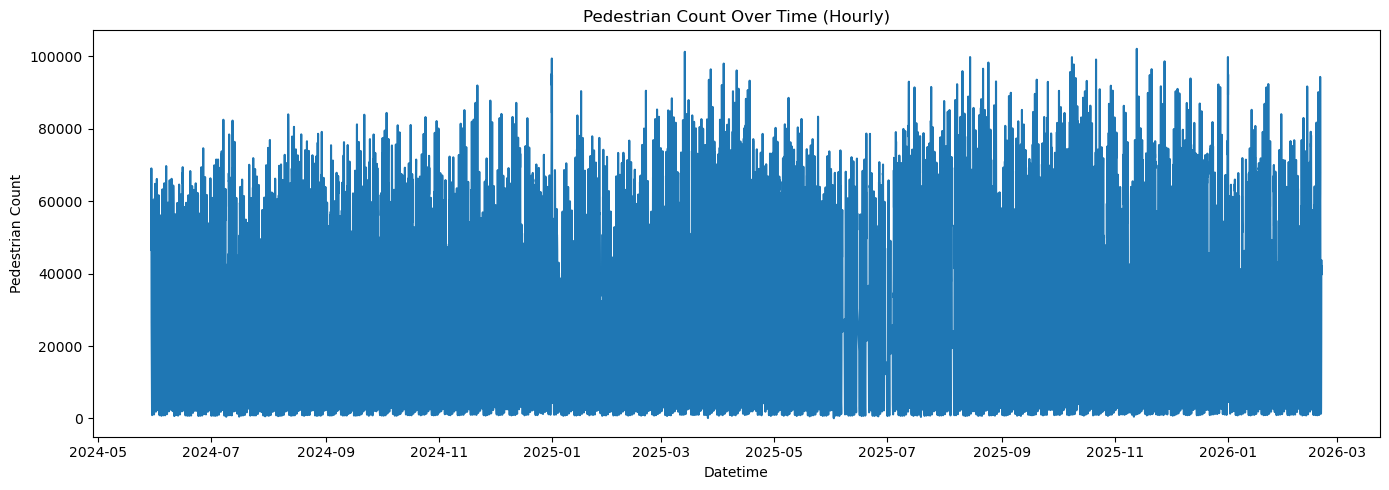

In [61]:
# Plot pedestrian counts over time.
plt.figure(figsize=(14, 5))
plt.plot(
    model_df["datetime_hour"],
    model_df["pedestriancount"]
)
plt.title("Pedestrian Count Over Time (Hourly)")
plt.xlabel("Datetime")
plt.ylabel("Pedestrian Count")
plt.tight_layout()
plt.show()

### 6.2 Average Pedestrian Count By Day Of Week

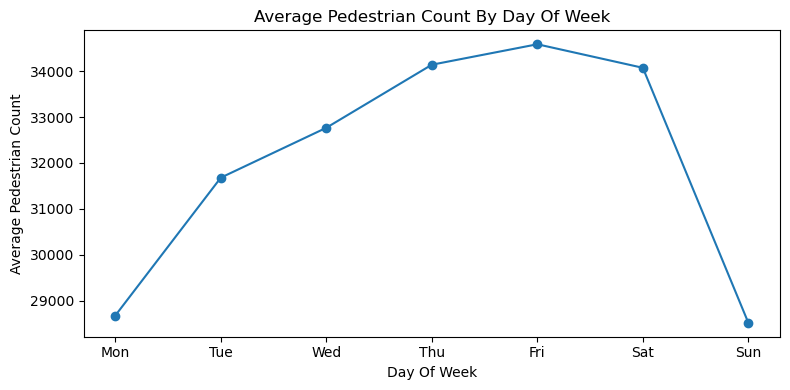

In [63]:
# Create a day-of-week column.
model_df["day_of_week"] = model_df[
    "datetime_hour"
].dt.dayofweek

# Group by day of week.
dow_pattern = model_df.groupby("day_of_week")[
    "pedestriancount"
].mean()

# Plot the day-of-week pattern.
plt.figure(figsize=(8, 4))
plt.plot(dow_pattern.index, dow_pattern.values, marker="o")
plt.title("Average Pedestrian Count By Day Of Week")
plt.xlabel("Day Of Week")
plt.ylabel("Average Pedestrian Count")
plt.xticks(
    ticks=range(7),
    labels=[
        "Mon", "Tue", "Wed",
        "Thu", "Fri", "Sat", "Sun"
    ]
)
plt.tight_layout()
plt.show()

### 6.3 Distributions Of Variables

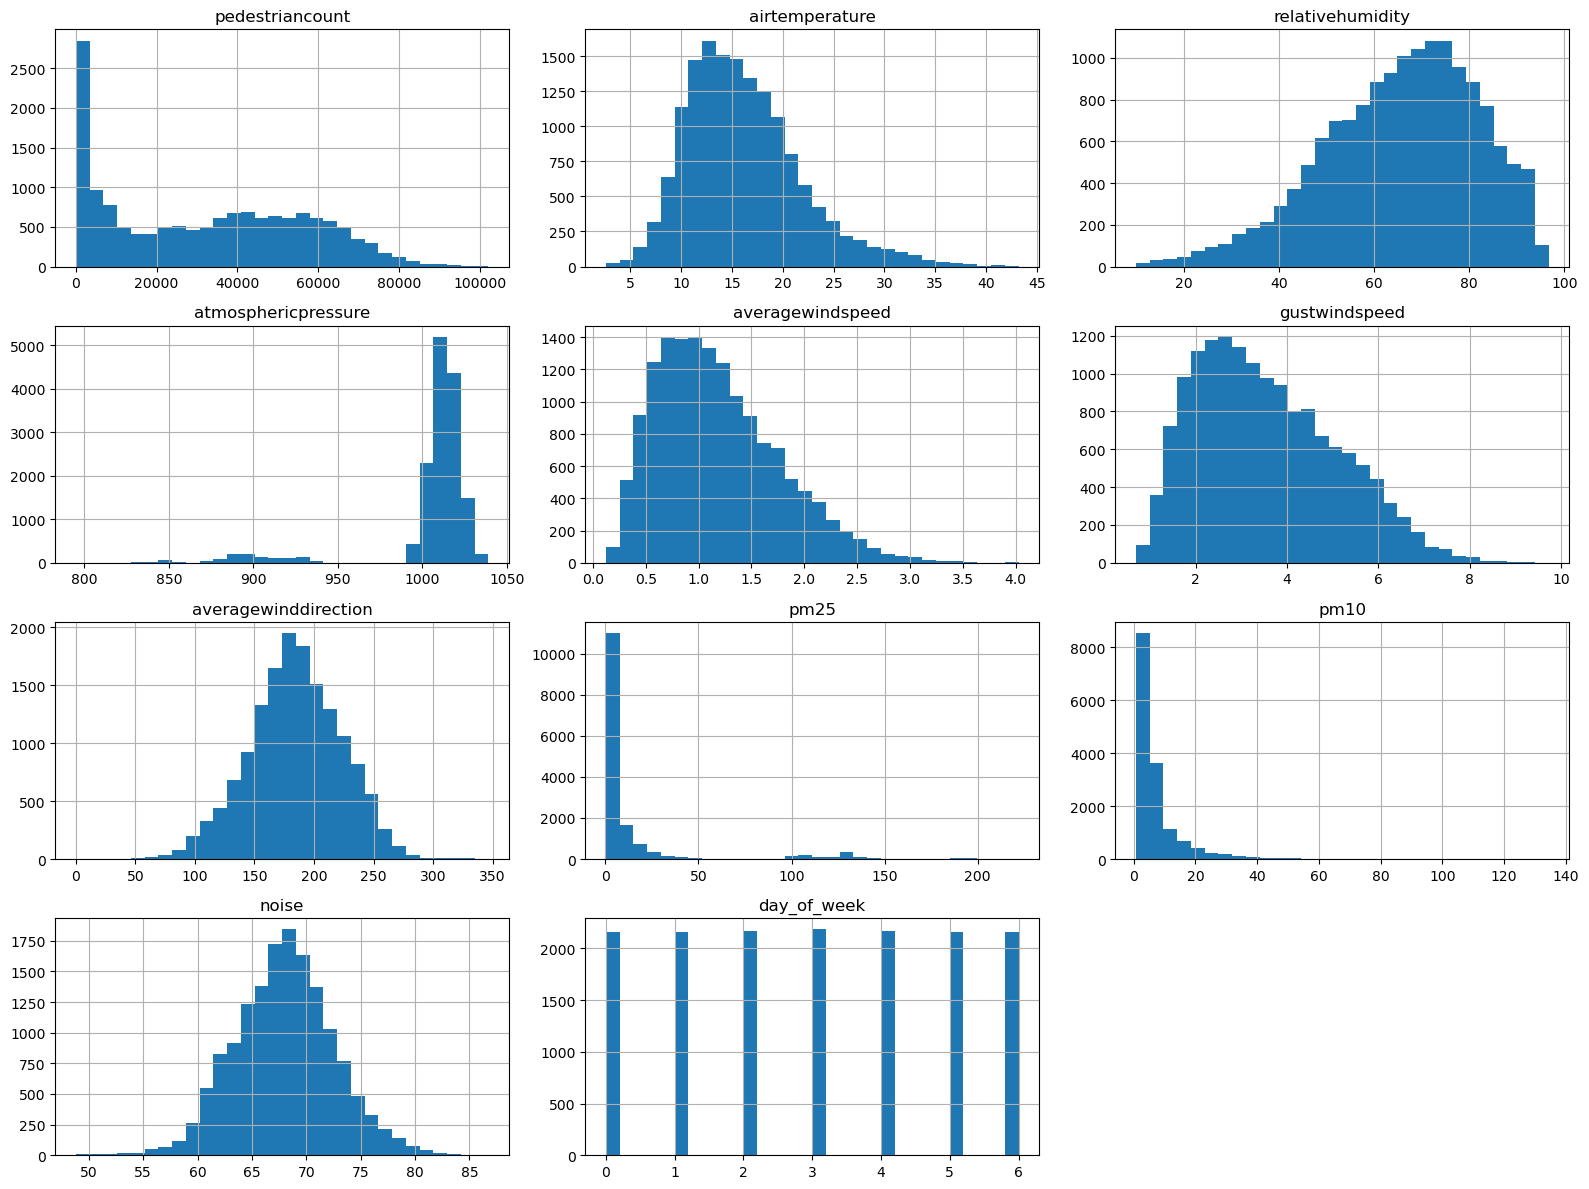

In [65]:
# Store numeric columns.
numeric_cols = model_df.select_dtypes(
    include=["int32", "int64", "float64"]
).columns

# Plot histograms for numeric columns.
model_df[numeric_cols].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

### 6.4 Correlation Matrix

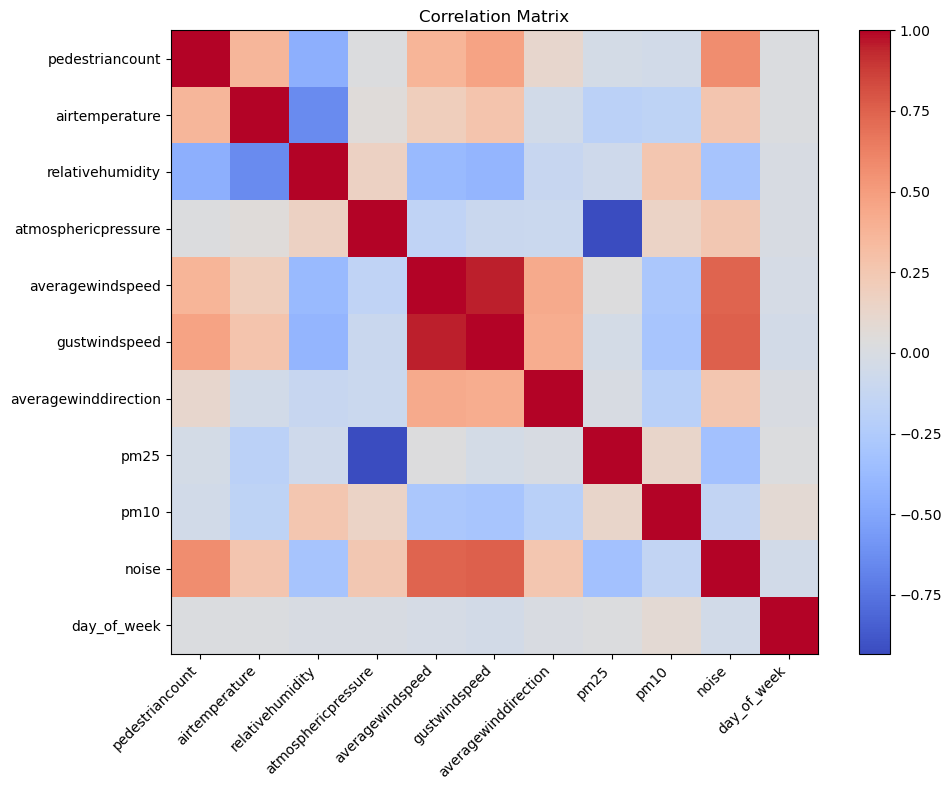

pedestriancount         1.000000
noise                   0.570037
gustwindspeed           0.470605
averagewindspeed        0.369485
airtemperature          0.365204
averagewinddirection    0.110778
atmosphericpressure     0.019206
day_of_week             0.017961
pm25                   -0.033080
pm10                   -0.041970
relativehumidity       -0.448898
Name: pedestriancount, dtype: float64


In [67]:
# Calculate the correlation matrix.
corr_matrix = model_df[numeric_cols].corr()

# Plot the correlation matrix.
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Print the correlation values with pedestrian count.
print(corr_matrix["pedestriancount"].sort_values(ascending=False))

## 7. Time Series Analysis

### 7.1 Pedestrian Count Over Time (24-Hour Rolling Mean)

In [70]:
# Create the hourly target series.
ts = model_df.set_index("datetime_hour")[
    "pedestriancount"
].sort_index()

# Check the first few rows.
print(ts.head())

datetime_hour
2024-05-29 13:00:00    57628
2024-05-29 14:00:00    46483
2024-05-29 15:00:00    49846
2024-05-29 16:00:00    58939
2024-05-29 17:00:00    69055
Name: pedestriancount, dtype: int32


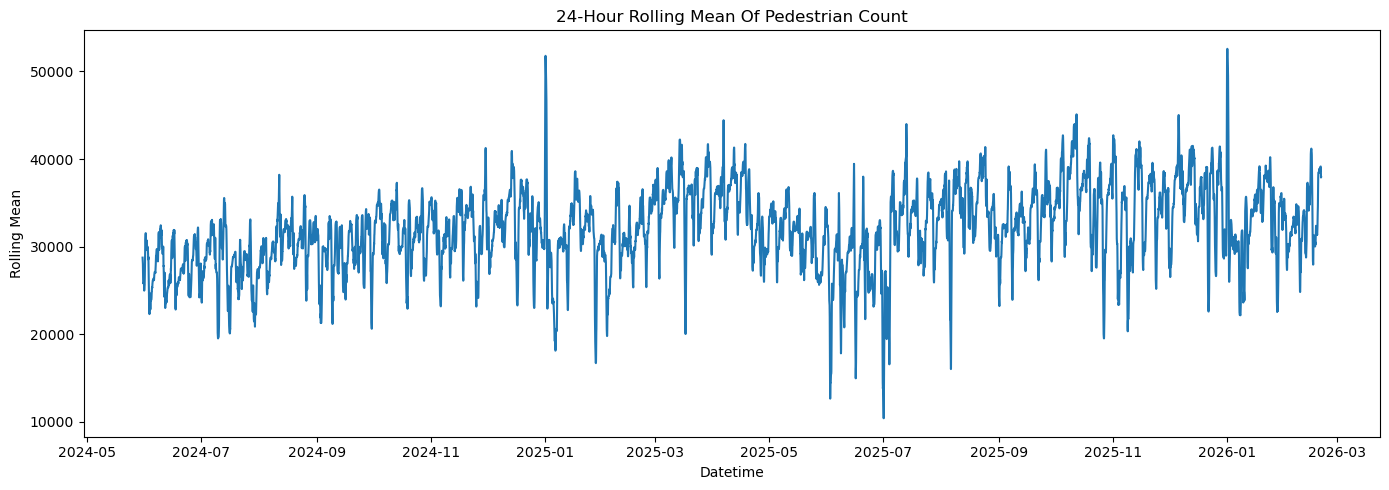

In [71]:
# Calculate the 24-hour rolling mean.
rolling_mean_24 = ts.rolling(24).mean()

# Plot the rolling mean only.
plt.figure(figsize=(14, 5))
plt.plot(rolling_mean_24)
plt.title("24-Hour Rolling Mean Of Pedestrian Count")
plt.xlabel("Datetime")
plt.ylabel("Rolling Mean")
plt.tight_layout()
plt.show()

### 7.2 Seasonal Pattern (24-Hour Cycle)

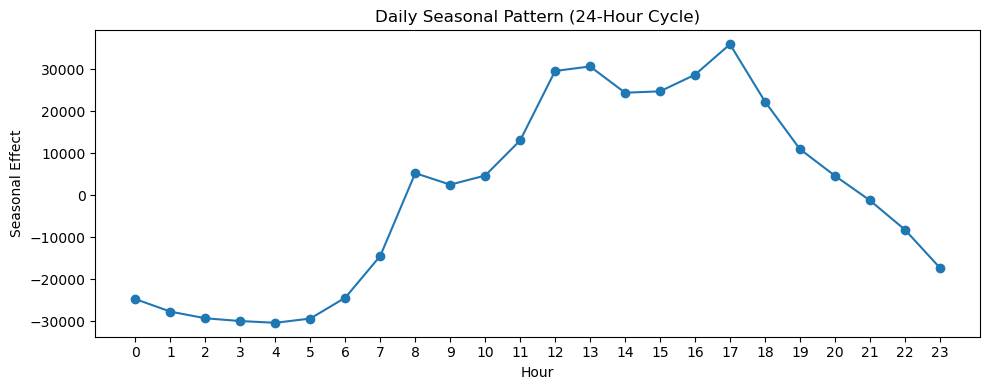

In [73]:
# Decompose the series using a 24-hour period.
decomp_24 = seasonal_decompose(
    ts,
    model="additive",
    period=24
)

# Store one seasonal cycle and align it to the actual hours.
seasonal_24 = pd.Series(
    decomp_24.seasonal[:24].values,
    index=ts.index[:24].hour
)

# Sort by actual hour.
seasonal_24 = seasonal_24.sort_index()

# Plot the corrected daily seasonal pattern.
plt.figure(figsize=(10, 4))
plt.plot(seasonal_24.index, seasonal_24.values, marker="o")
plt.title("Daily Seasonal Pattern (24-Hour Cycle)")
plt.xlabel("Hour")
plt.ylabel("Seasonal Effect")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

### 7.3 Autocorrelation Of Pedestrian Count

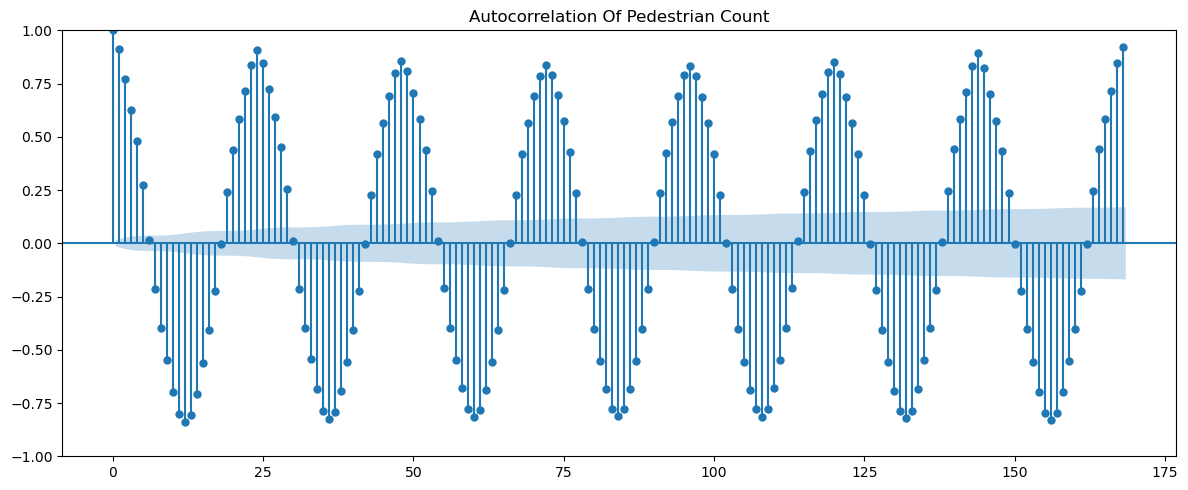

In [75]:
# Plot autocorrelation for one week of hourly lags.
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(ts, lags=168, ax=ax)
ax.set_title("Autocorrelation Of Pedestrian Count")
plt.tight_layout()
plt.show()

### 7.4 Augmented Dickey-Fuller Test

In [77]:
# Run the Augmented Dickey-Fuller test.
adf_result = adfuller(ts)

# Print the results.
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -12.167913283655542
p-value: 1.4429926404974187e-22
Critical Values:
1%: -3.4307825096141857
5%: -2.861731150652329
10%: -2.5668717448588714


## 8. Feature Engineering

### 8.1 Creating Time Features

In [80]:
# Create a copy for feature engineering.
features_df = model_df.copy()

# Extract calendar features.
features_df["hour"] = features_df["datetime_hour"].dt.hour
features_df["day_of_week"] = (
    features_df["datetime_hour"].dt.dayofweek
)
features_df["month"] = features_df["datetime_hour"].dt.month
features_df["is_weekend"] = (
    features_df["day_of_week"] >= 5
).astype(int)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour", "day_of_week", "month", 
            "is_weekend"
        ]
    ].head()
)

        datetime_hour  hour  day_of_week  month  is_weekend
0 2024-05-29 13:00:00    13            2      5           0
1 2024-05-29 14:00:00    14            2      5           0
2 2024-05-29 15:00:00    15            2      5           0
3 2024-05-29 16:00:00    16            2      5           0
4 2024-05-29 17:00:00    17            2      5           0


### 8.2 Creating Cyclical Time Features

In [82]:
# Hour and day of week are cyclical, not linear.
# Create cyclical hour features.
features_df["hour_sin"] = np.sin(
    2 * np.pi * features_df["hour"] / 24
)
features_df["hour_cos"] = np.cos(
    2 * np.pi * features_df["hour"] / 24
)

# Create cyclical day-of-week features.
features_df["dow_sin"] = np.sin(
    2 * np.pi * features_df["day_of_week"] / 7
)
features_df["dow_cos"] = np.cos(
    2 * np.pi * features_df["day_of_week"] / 7
)

# Convert cyclical month features.
features_df["month_sin"] = np.sin(
    2 * np.pi * features_df["month"] / 12
)
features_df["month_cos"] = np.cos(
    2 * np.pi * features_df["month"] / 12
)

# Check the result.
print(
    features_df[
        [
            "datetime_hour", "hour_sin", "hour_cos",
            "dow_sin", "dow_cos", "month_sin", 
            "month_cos"
        ]
    ].head()
)

        datetime_hour  hour_sin  hour_cos   dow_sin   dow_cos  month_sin  \
0 2024-05-29 13:00:00 -0.258819 -0.965926  0.974928 -0.222521        0.5   
1 2024-05-29 14:00:00 -0.500000 -0.866025  0.974928 -0.222521        0.5   
2 2024-05-29 15:00:00 -0.707107 -0.707107  0.974928 -0.222521        0.5   
3 2024-05-29 16:00:00 -0.866025 -0.500000  0.974928 -0.222521        0.5   
4 2024-05-29 17:00:00 -0.965926 -0.258819  0.974928 -0.222521        0.5   

   month_cos  
0  -0.866025  
1  -0.866025  
2  -0.866025  
3  -0.866025  
4  -0.866025  


### 8.3 Creating Cyclical Wind Direction Features

In [84]:
# Convert wind direction into cyclical form.
features_df["wind_dir_sin"] = np.sin(
    2 * np.pi * features_df["averagewinddirection"] / 360
)
features_df["wind_dir_cos"] = np.cos(
    2 * np.pi * features_df["averagewinddirection"] / 360
)

# Check the result.
print(
    features_df[
        [
            "averagewinddirection",
            "wind_dir_sin",
            "wind_dir_cos"
        ]
    ].head()
)

   averagewinddirection  wind_dir_sin  wind_dir_cos
0            252.000000     -0.951057     -0.309017
1            240.148148     -0.867315     -0.497759
2            190.925926     -0.189540     -0.981873
3            238.040000     -0.848418     -0.529327
4            226.714286     -0.727944     -0.685637


### 8.4 Creating Lag Features

In [86]:
# Create lagged pedestrian count features.
features_df["lag_1"] = (
    features_df["pedestriancount"].shift(1)
)

features_df["lag_24"] = (
    features_df["pedestriancount"].shift(24)
)

features_df["lag_168"] = (
    features_df["pedestriancount"].shift(168)
)

# Check the result.
print(
    features_df[
        [
            "lag_1", "lag_24", "lag_168"
        ]
    ].head(25)
)

      lag_1   lag_24  lag_168
0       NaN      NaN      NaN
1   57628.0      NaN      NaN
2   46483.0      NaN      NaN
3   49846.0      NaN      NaN
4   58939.0      NaN      NaN
5   69055.0      NaN      NaN
6   48776.0      NaN      NaN
7   31556.0      NaN      NaN
8   26512.0      NaN      NaN
9   21317.0      NaN      NaN
10  16927.0      NaN      NaN
11   8038.0      NaN      NaN
12   3293.0      NaN      NaN
13   1913.0      NaN      NaN
14   1160.0      NaN      NaN
15    912.0      NaN      NaN
16   1089.0      NaN      NaN
17   2603.0      NaN      NaN
18   9251.0      NaN      NaN
19  21117.0      NaN      NaN
20  48415.0      NaN      NaN
21  39618.0      NaN      NaN
22  30712.0      NaN      NaN
23  34333.0      NaN      NaN
24  60229.0  57628.0      NaN


### 8.5 Creating Rolling Features

In [88]:
# Create rolling mean features from past counts.
features_df["rolling_mean_24"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(24)
    .mean()
)

features_df["rolling_mean_168"] = (
    features_df["pedestriancount"]
    .shift(1)
    .rolling(168)
    .mean()
)

# Check the result.
print(
    features_df[
        [
            "rolling_mean_24", "rolling_mean_168"
        ]
    ].head(25)
)

    rolling_mean_24  rolling_mean_168
0               NaN               NaN
1               NaN               NaN
2               NaN               NaN
3               NaN               NaN
4               NaN               NaN
5               NaN               NaN
6               NaN               NaN
7               NaN               NaN
8               NaN               NaN
9               NaN               NaN
10              NaN               NaN
11              NaN               NaN
12              NaN               NaN
13              NaN               NaN
14              NaN               NaN
15              NaN               NaN
16              NaN               NaN
17              NaN               NaN
18              NaN               NaN
19              NaN               NaN
20              NaN               NaN
21              NaN               NaN
22              NaN               NaN
23              NaN               NaN
24     28738.416667               NaN


### 8.6 Removing NA Rows

In [90]:
# Remove rows with NAs.
features_df = features_df.dropna().reset_index(drop=True)

# Check the result.
print(features_df.info())
print(features_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14998 entries, 0 to 14997
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime_hour         14998 non-null  datetime64[ns]
 1   pedestriancount       14998 non-null  int32         
 2   airtemperature        14998 non-null  float64       
 3   relativehumidity      14998 non-null  float64       
 4   atmosphericpressure   14998 non-null  float64       
 5   averagewindspeed      14998 non-null  float64       
 6   gustwindspeed         14998 non-null  float64       
 7   averagewinddirection  14998 non-null  float64       
 8   pm25                  14998 non-null  float64       
 9   pm10                  14998 non-null  float64       
 10  noise                 14998 non-null  float64       
 11  day_of_week           14998 non-null  int32         
 12  hour                  14998 non-null  int32         
 13  month           

### 8.7 Removing Unnecessary Features

In [92]:
# Drop raw columns that now have cyclical replacements.
features_df = features_df.drop(
    columns=[
        "averagewinddirection",
        "hour",
        "day_of_week",
        "month",
    ]
)

# Reorder the columns into a cleaner structure.
features_df = features_df[
    [
        "datetime_hour",
        "pedestriancount",
        "airtemperature",
        "relativehumidity",
        "atmosphericpressure",
        "averagewindspeed",
        "gustwindspeed",
        "pm25",
        "pm10",
        "noise",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos",
        "wind_dir_sin",
        "wind_dir_cos",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_mean_24",
        "rolling_mean_168",
    ]
]

# Check the result.
print(features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14998 entries, 0 to 14997
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime_hour        14998 non-null  datetime64[ns]
 1   pedestriancount      14998 non-null  int32         
 2   airtemperature       14998 non-null  float64       
 3   relativehumidity     14998 non-null  float64       
 4   atmosphericpressure  14998 non-null  float64       
 5   averagewindspeed     14998 non-null  float64       
 6   gustwindspeed        14998 non-null  float64       
 7   pm25                 14998 non-null  float64       
 8   pm10                 14998 non-null  float64       
 9   noise                14998 non-null  float64       
 10  is_weekend           14998 non-null  int32         
 11  hour_sin             14998 non-null  float64       
 12  hour_cos             14998 non-null  float64       
 13  dow_sin              14998 non-

## 9. Preparing Train/Val/Test Splits

### 9.1 Splitting The Data By Time

In [95]:
# Set the split sizes (80:10:10).
train_size = int(len(features_df) * 0.8)
val_size = int(len(features_df) * 0.1)

# Split the data in chronological order.
train_df = features_df.iloc[:train_size].copy()
val_df = features_df.iloc[
    train_size:train_size + val_size
].copy()
test_df = features_df.iloc[
    train_size + val_size:
].copy()

# Check the shapes.
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(11998, 24)
(1499, 24)
(1501, 24)


In [96]:
# Checking The Split Ranges.
print("Train range:")
print(train_df["datetime_hour"].min())
print(train_df["datetime_hour"].max())

print("\nValidation range:")
print(val_df["datetime_hour"].min())
print(val_df["datetime_hour"].max())

print("\nTest range:")
print(test_df["datetime_hour"].min())
print(test_df["datetime_hour"].max())

Train range:
2024-06-05 13:00:00
2025-10-18 10:00:00

Validation range:
2025-10-18 11:00:00
2025-12-19 21:00:00

Test range:
2025-12-19 22:00:00
2026-02-20 10:00:00


### 9.2 Separating Features And Target

In [98]:
# Store the target column name.
target_col = "pedestriancount"

# Store the feature column names.
feature_cols = [
    col for col in features_df.columns
    if col not in ["datetime_hour", target_col]
]

# Create X and y for each split.
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Check the shapes.
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(11998, 22) (11998,)
(1499, 22) (1499,)
(1501, 22) (1501,)


### 9.3 Scaling The Features

In [100]:
# Create the scaler.
scaler = StandardScaler()

# Fit on training features only.
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test features.
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Check the shapes.
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)
print(X_train_scaled[:5])

(11998, 22)
(1499, 22)
(1501, 22)
[[-0.25917082  0.29404521  0.44458648 -0.20251436 -0.45919765 -0.10819435
   1.05388729  0.60401279 -0.63129335 -0.36596644 -1.36636342  1.37933732
  -0.3088925   0.25826753 -1.27852587 -1.10176994  0.1948997   1.103844
   0.92658633  1.08650448 -1.1765486  -1.54401732]
 [-0.26879797  0.23225894  0.45019736 -0.17397887 -0.24207515 -0.16932953
   0.73538055  0.53784354 -0.63129335 -0.7070213  -1.2250719   1.37933732
  -0.3088925   0.25826753 -1.27852587  0.21591715 -0.80547699  0.79740125
   0.40018736  0.62311381 -1.20475612 -1.55725255]
 [-0.20362957 -0.17301712  0.46141912 -0.05270306  0.06732442 -0.18266811
   0.6747126   0.15317963 -0.63129335 -0.99989174 -1.00030954  1.37933732
  -0.3088925   0.25826753 -1.27852587  0.22921459 -0.80371765  0.48830997
   0.53008931  0.76294179 -1.18499347 -1.56323808]
 [-0.20807287 -0.24920273  0.46325124 -0.28812081 -0.29635577 -0.24046865
   0.4168738   0.22552467 -0.63129335 -1.22461914 -0.70739354  1.37933732
 